# Painel analítico

Este notebook reúne o resumo gerencial, as respostas analíticas e as métricas do modelo já geradas pelo pipeline.

In [1]:


import sys
from pathlib import Path


DIRETORIO_NOTEBOOKS = Path.cwd()
if not (DIRETORIO_NOTEBOOKS / "ambiente_notebook.py").exists():
    candidato = DIRETORIO_NOTEBOOKS / "notebooks"
    if candidato.exists():
        DIRETORIO_NOTEBOOKS = candidato
if str(DIRETORIO_NOTEBOOKS) not in sys.path:
    sys.path.insert(0, str(DIRETORIO_NOTEBOOKS))

from ambiente_notebook import adicionar_raiz_no_syspath, resolver_caminho_projeto

DIRETORIO_RAIZ = adicionar_raiz_no_syspath()

import json

import pandas as pd
from IPython.display import Image, Markdown, display

from src.passos_magicos_dt.config import ANALYTICS_DIR, MODEL_DIR

In [2]:
carga_painel = json.loads((ANALYTICS_DIR / "painel_analitico.json").read_text(encoding="utf-8"))
resumo_painel = pd.DataFrame(carga_painel["resumo_painel"].items(), columns=["indicador", "valor"])
resumo_painel

,indicador,valor
0,base_registros,3030
1,alunos_unicos,1661
2,pares_modelagem,1365
3,ano_mais_recente,2024
4,ian_medio_mais_recente,7.68
5,taxa_risco_mais_recente,46.2%
6,variacao_ida_2022_2024,+0.26
7,modelo_final,regressao_logistica
8,threshold_final,0.17
9,recall_holdout,0.58


## 1. Perguntas analíticas

## Pergunta 1 - Adequacao do nivel (IAN)

**Resposta:** A taxa de alunos em risco caiu de 69.9% em 2022 para 46.2% em 2024.  
**Número-chave:** `46.2%`  
**Leitura gerencial:** O programa melhora a adequacao de nivel ao longo do tempo, mas ainda termina 2024 com uma base relevante em risco.  
**Ação recomendada:** Manter trilhas preventivas para alunos em defasagem moderada antes que migrem para risco severo.

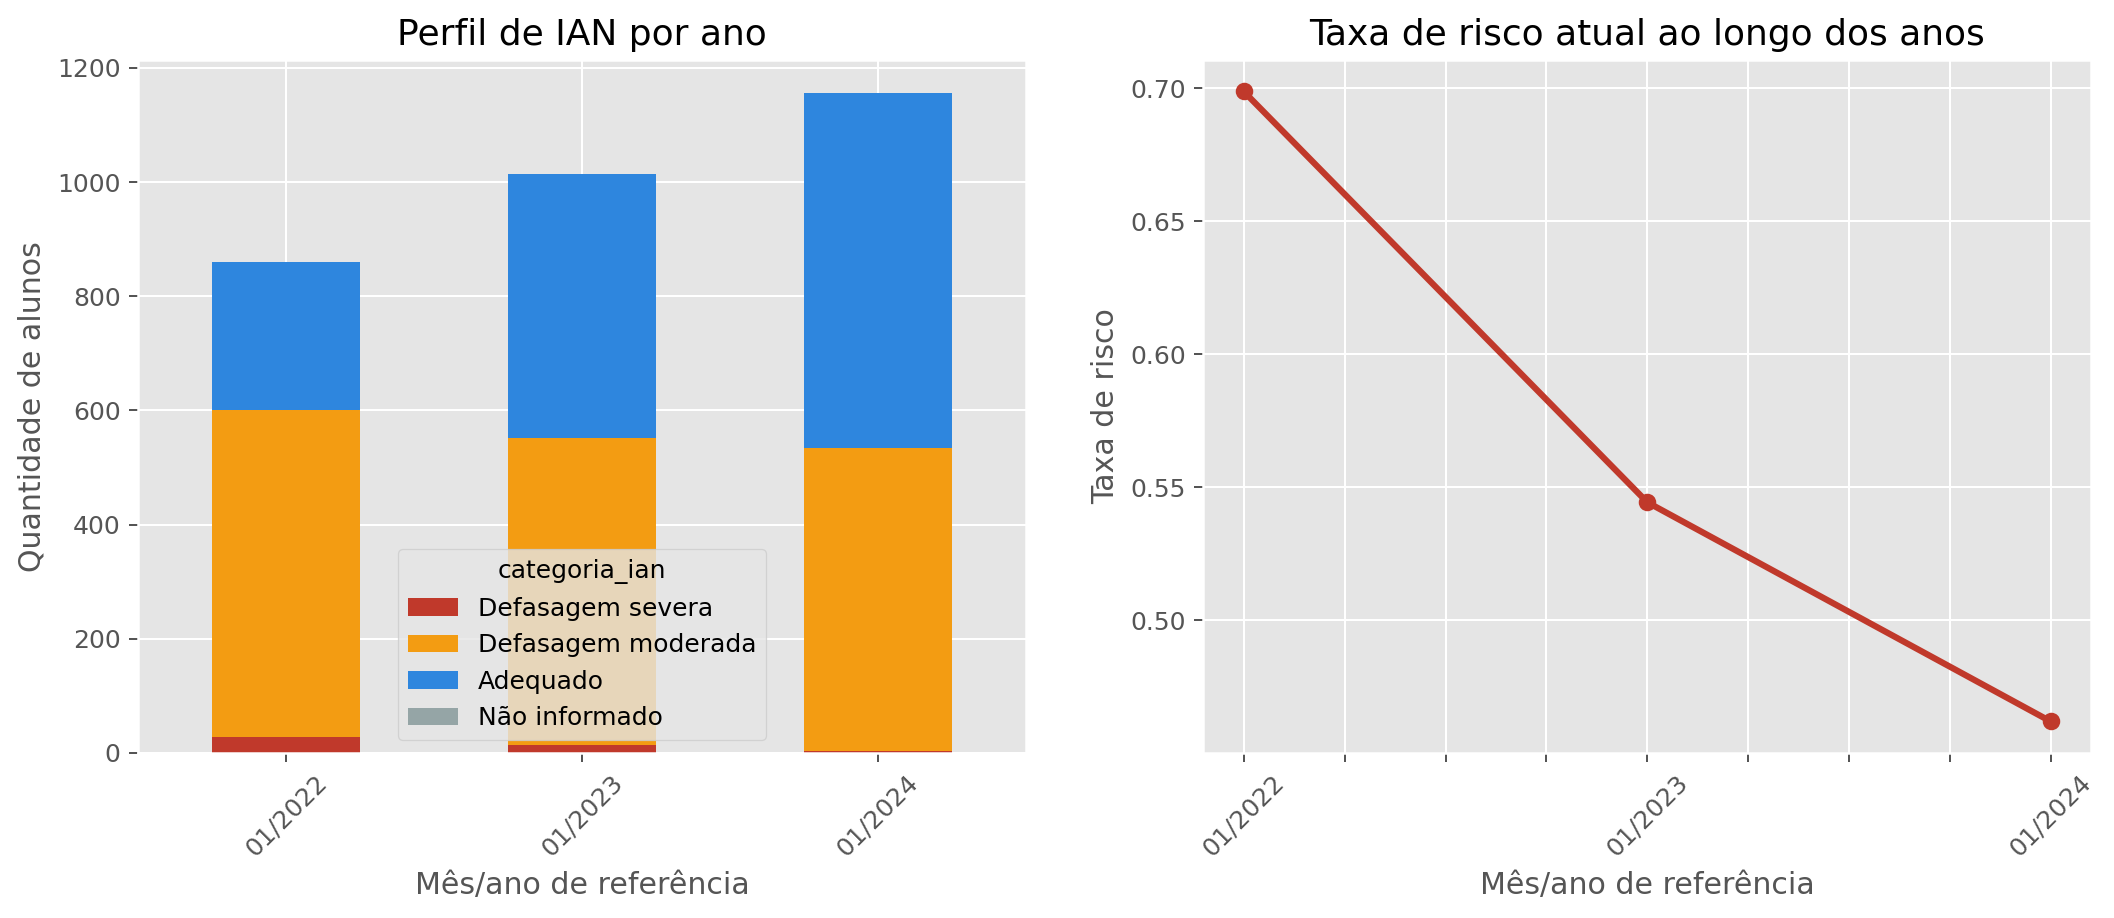

## Pergunta 2 - Desempenho academico (IDA)

**Resposta:** O IDA medio saiu de 6.09 para 6.66 no periodo, com leve acomodacao em 2024 frente a 2023.  
**Número-chave:** `+0.26`  
**Leitura gerencial:** O ganho academico existe, mas nao e linear em todos os ciclos.  
**Ação recomendada:** Direcionar reforco academico aos ciclos em que o IDA desacelera para evitar acomodacao do aprendizado.

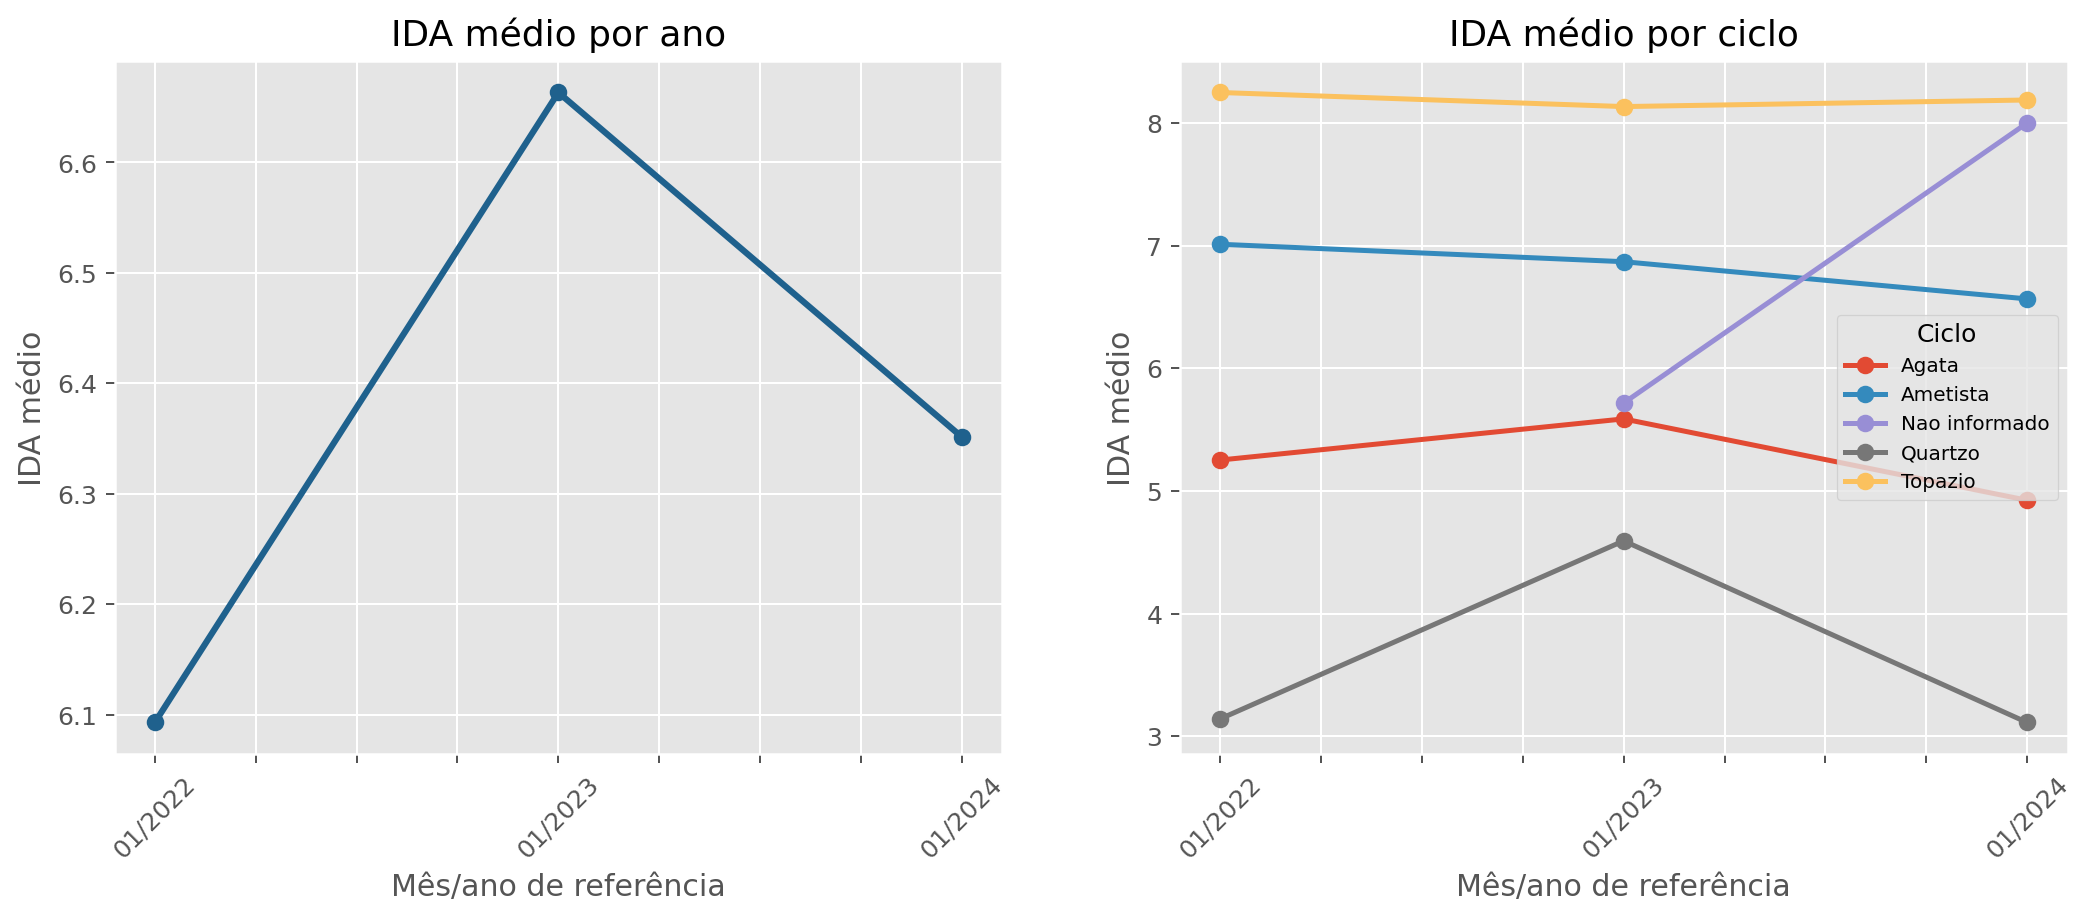

## Pergunta 3 - Engajamento nas atividades (IEG)

**Resposta:** O engajamento tem relacao positiva com o desempenho e o ponto de virada: corr(IEG, IDA)=0.54 e corr(IEG, IPV)=0.56.  
**Número-chave:** `0.54 / 0.56`  
**Leitura gerencial:** Engajamento nao e so participacao: ele antecipa resultado academico e virada positiva.  
**Ação recomendada:** Usar quedas de IEG como gatilho operacional para intervencao rapida por monitoria e relacionamento.

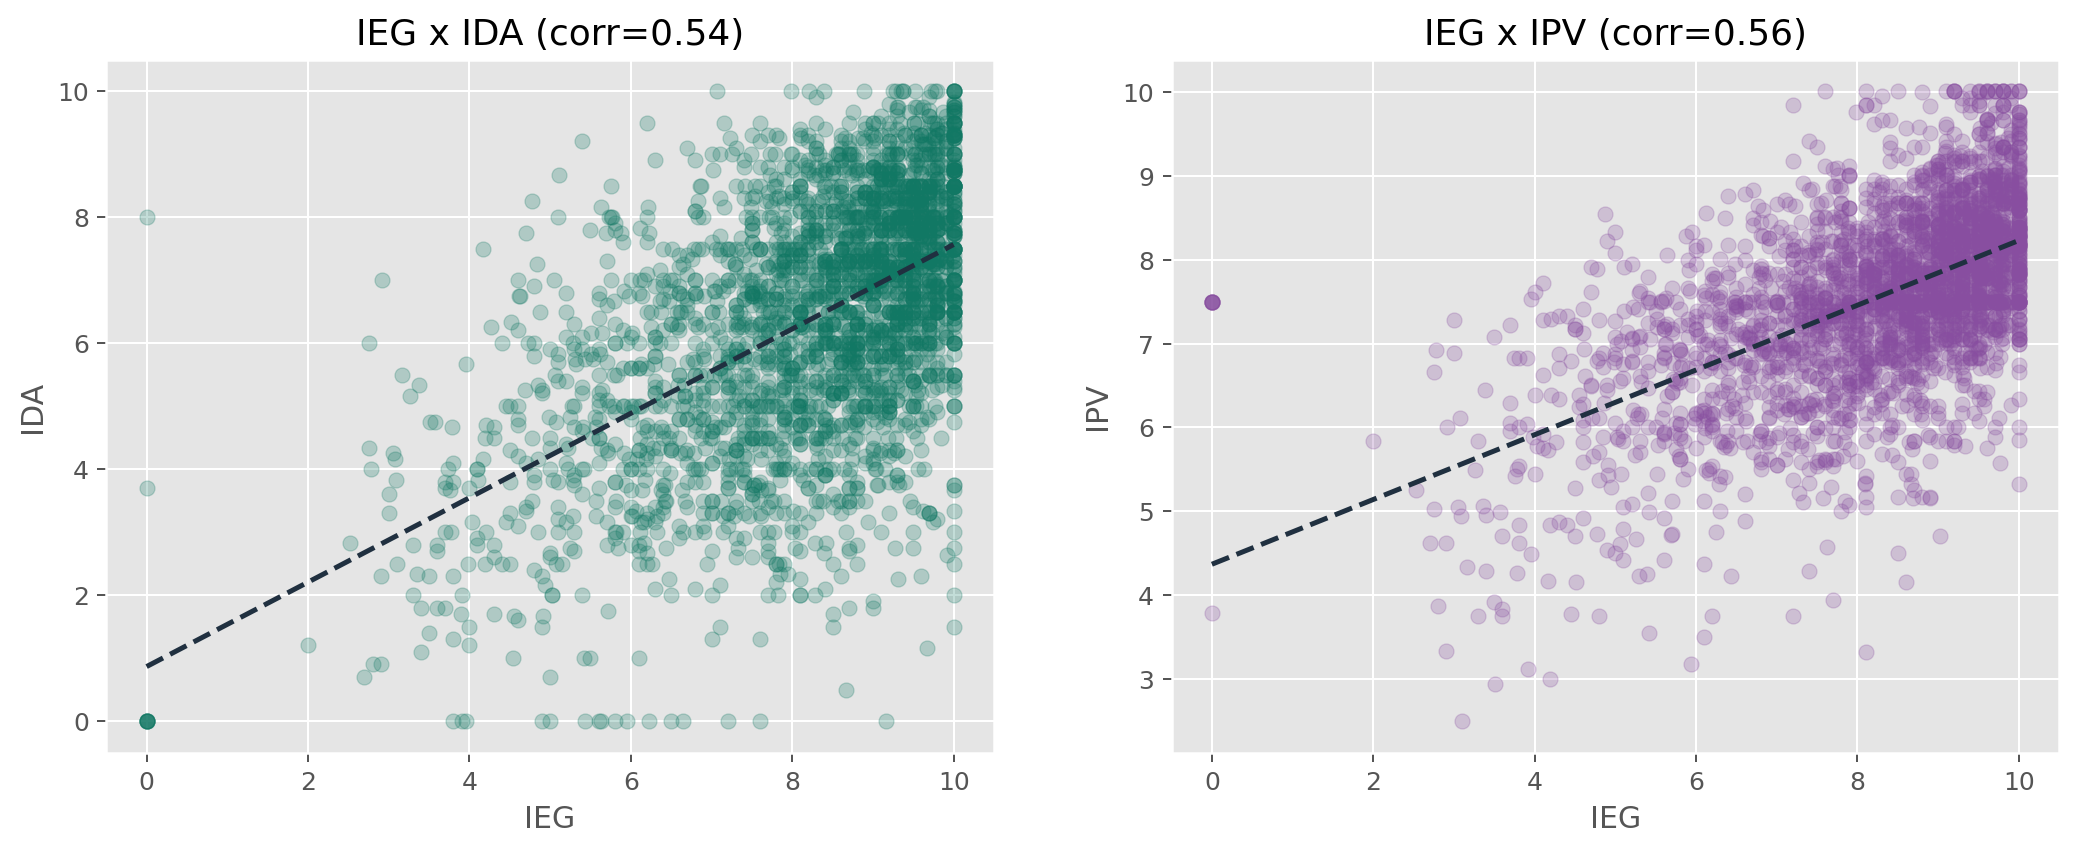

## Pergunta 4 - Autoavaliacao (IAA)

**Resposta:** A autoavaliacao e parcialmente coerente com o desempenho real, mas a correlacao e fraca: corr(IAA, IDA)=0.12 e corr(IAA, IEG)=0.13.  
**Número-chave:** `0.12`  
**Leitura gerencial:** A percepcao do aluno ajuda, mas sozinha nao explica o que realmente acontece no desempenho.  
**Ação recomendada:** Combinar autoavaliacao com sinais objetivos de engajamento e desempenho antes de decidir uma intervencao.

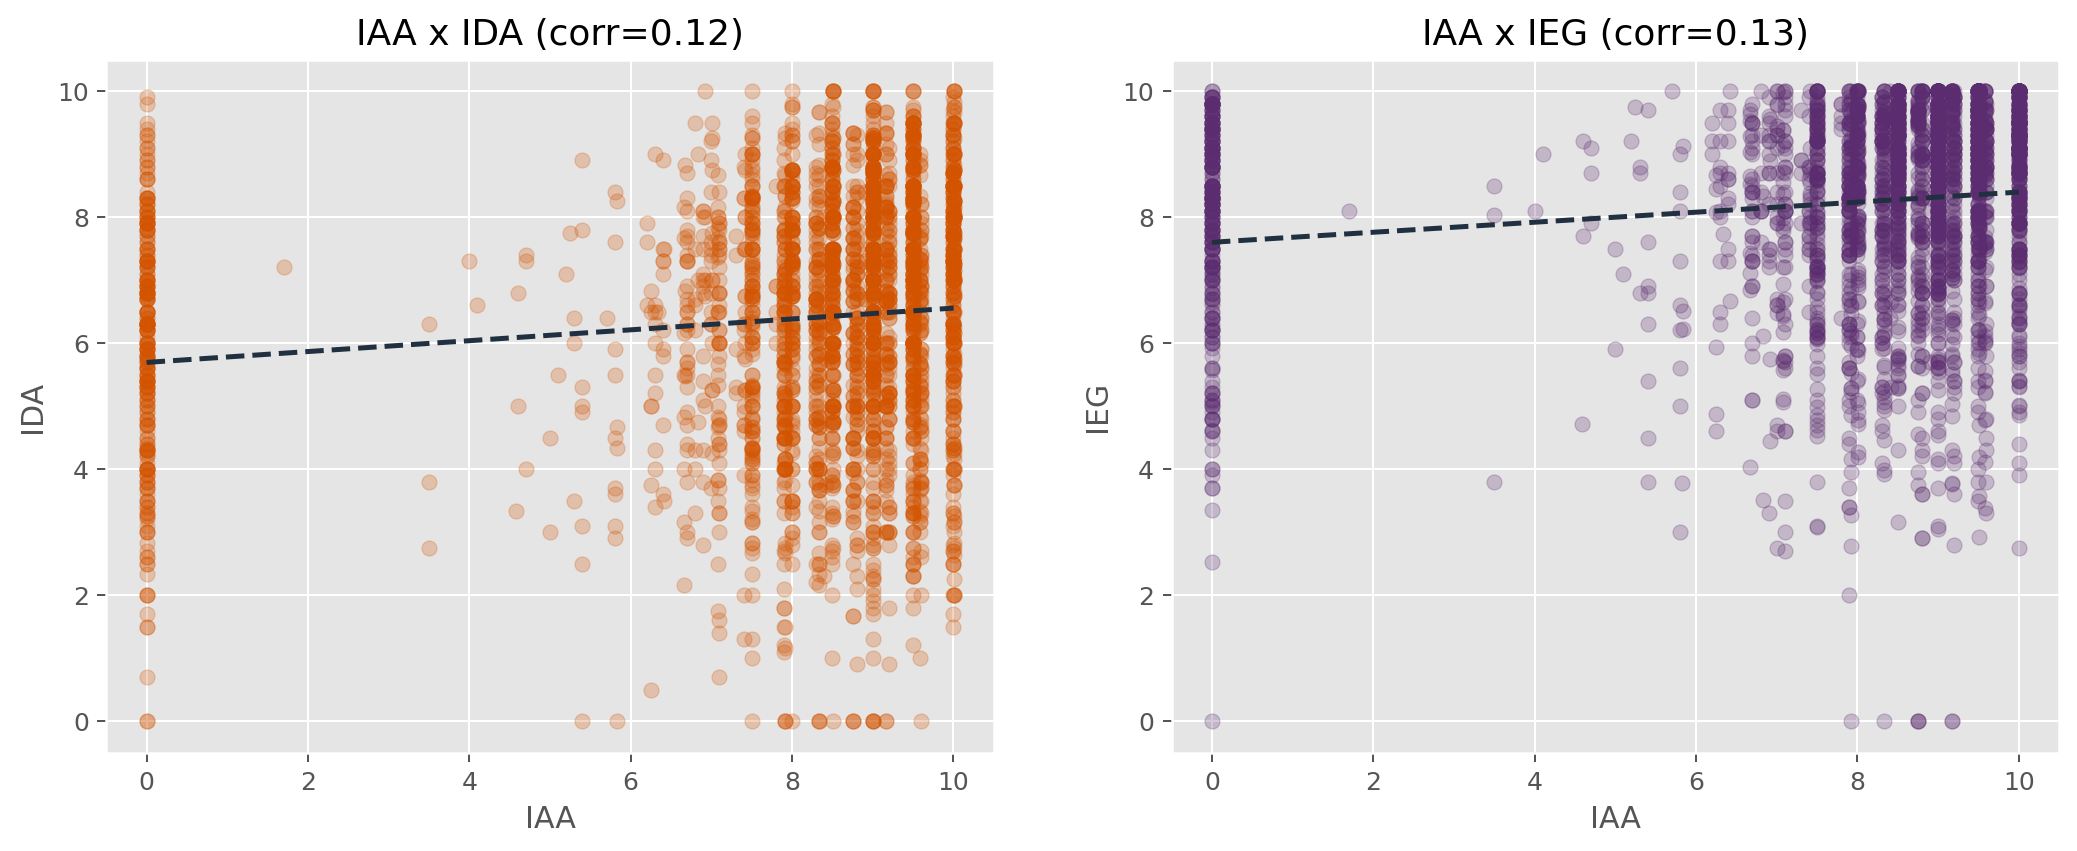

## Pergunta 5 - Aspectos psicossociais (IPS)

**Resposta:** Os padroes psicossociais antecedem mudancas de risco: a media de IPS difere em 0.60 pontos entre quem entra ou permanece em risco e quem segue fora de risco.  
**Número-chave:** `0.60`  
**Leitura gerencial:** O bloco psicossocial aparece antes da piora academica e pode ser usado como alerta preventivo.  
**Ação recomendada:** Priorizar suporte psicossocial e contato com familia nos perfis com pior IPS mesmo antes da queda do INDE.

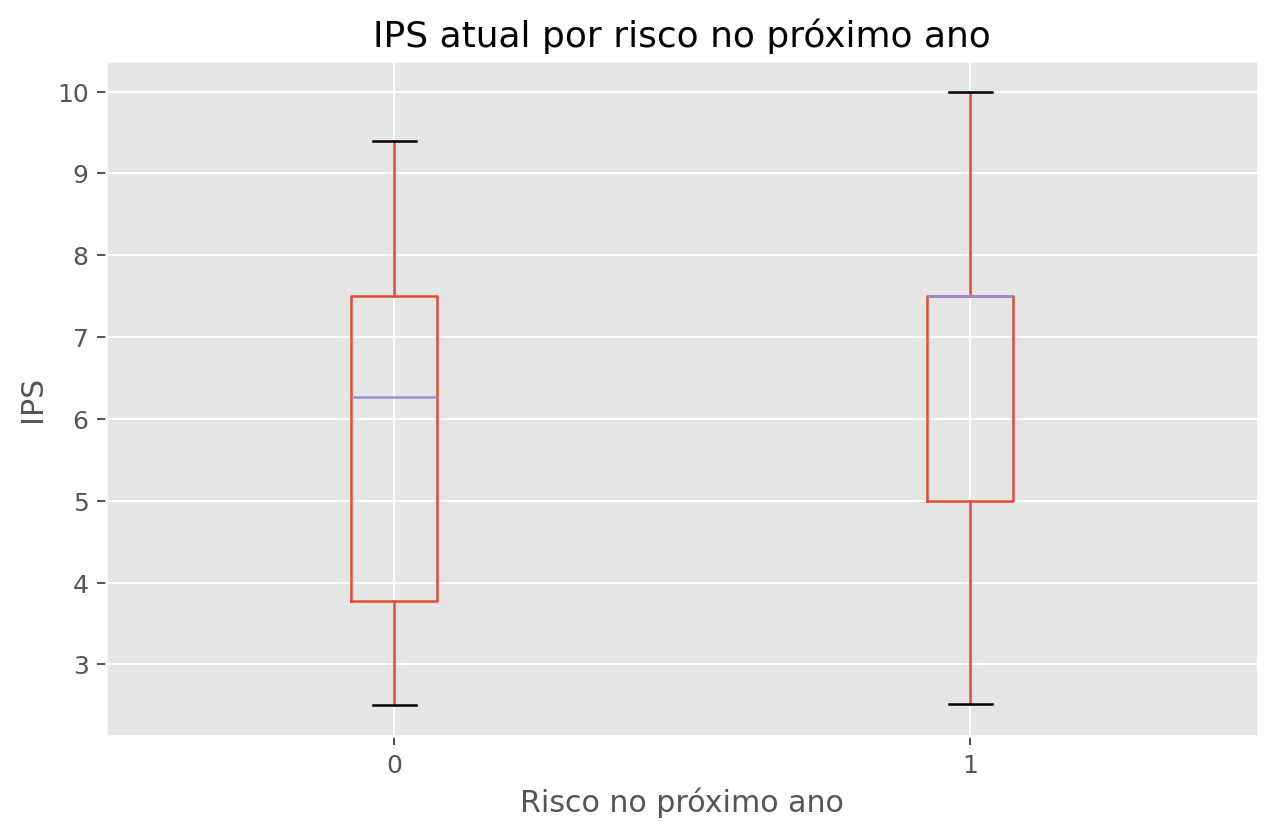

## Pergunta 6 - Aspectos psicopedagogicos (IPP)

**Resposta:** O IPP acompanha a defasagem: a diferenca entre o maior e o menor valor medio de IPP e 0.67.  
**Número-chave:** `0.67`  
**Leitura gerencial:** As avaliacoes psicopedagogicas reforcam o diagnostico de defasagem e ajudam a qualificar a priorizacao.  
**Ação recomendada:** Usar IPP para diferenciar alunos com defasagem estrutural de casos mais pontuais de oscilacao academica.

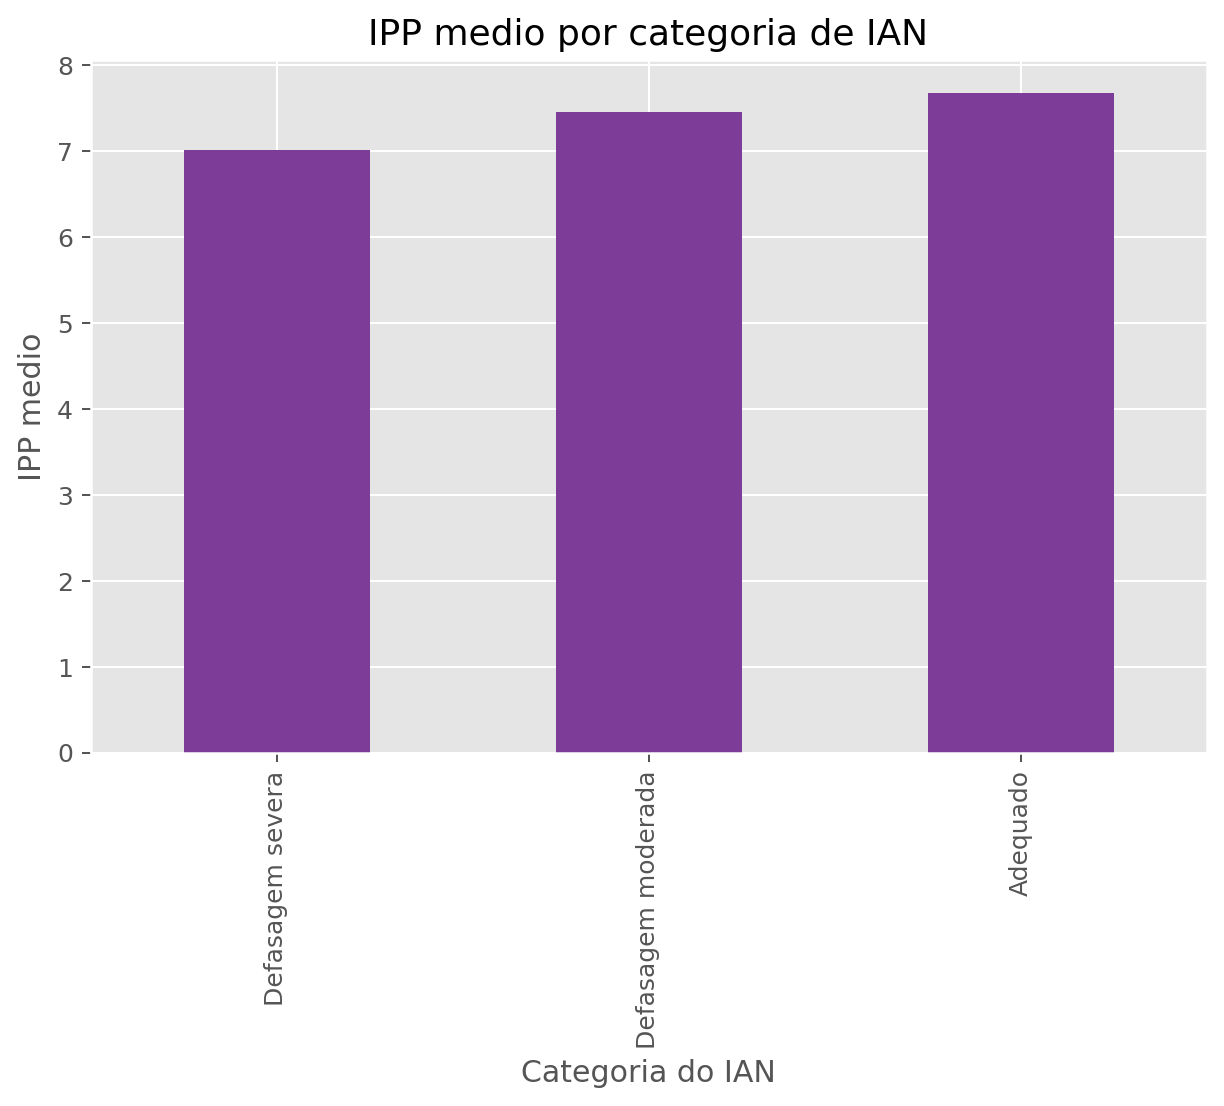

## Pergunta 7 - Ponto de virada (IPV)

**Resposta:** O IPV e mais influenciado por ipp, com correlacao de 0.61.  
**Número-chave:** `0.61`  
**Leitura gerencial:** A virada positiva depende de um conjunto de sinais academicos e comportamentais, nao de um unico evento.  
**Ação recomendada:** Tratar o IPV como indicador de combinacao de sinais e nao apenas como resultado final do ano.

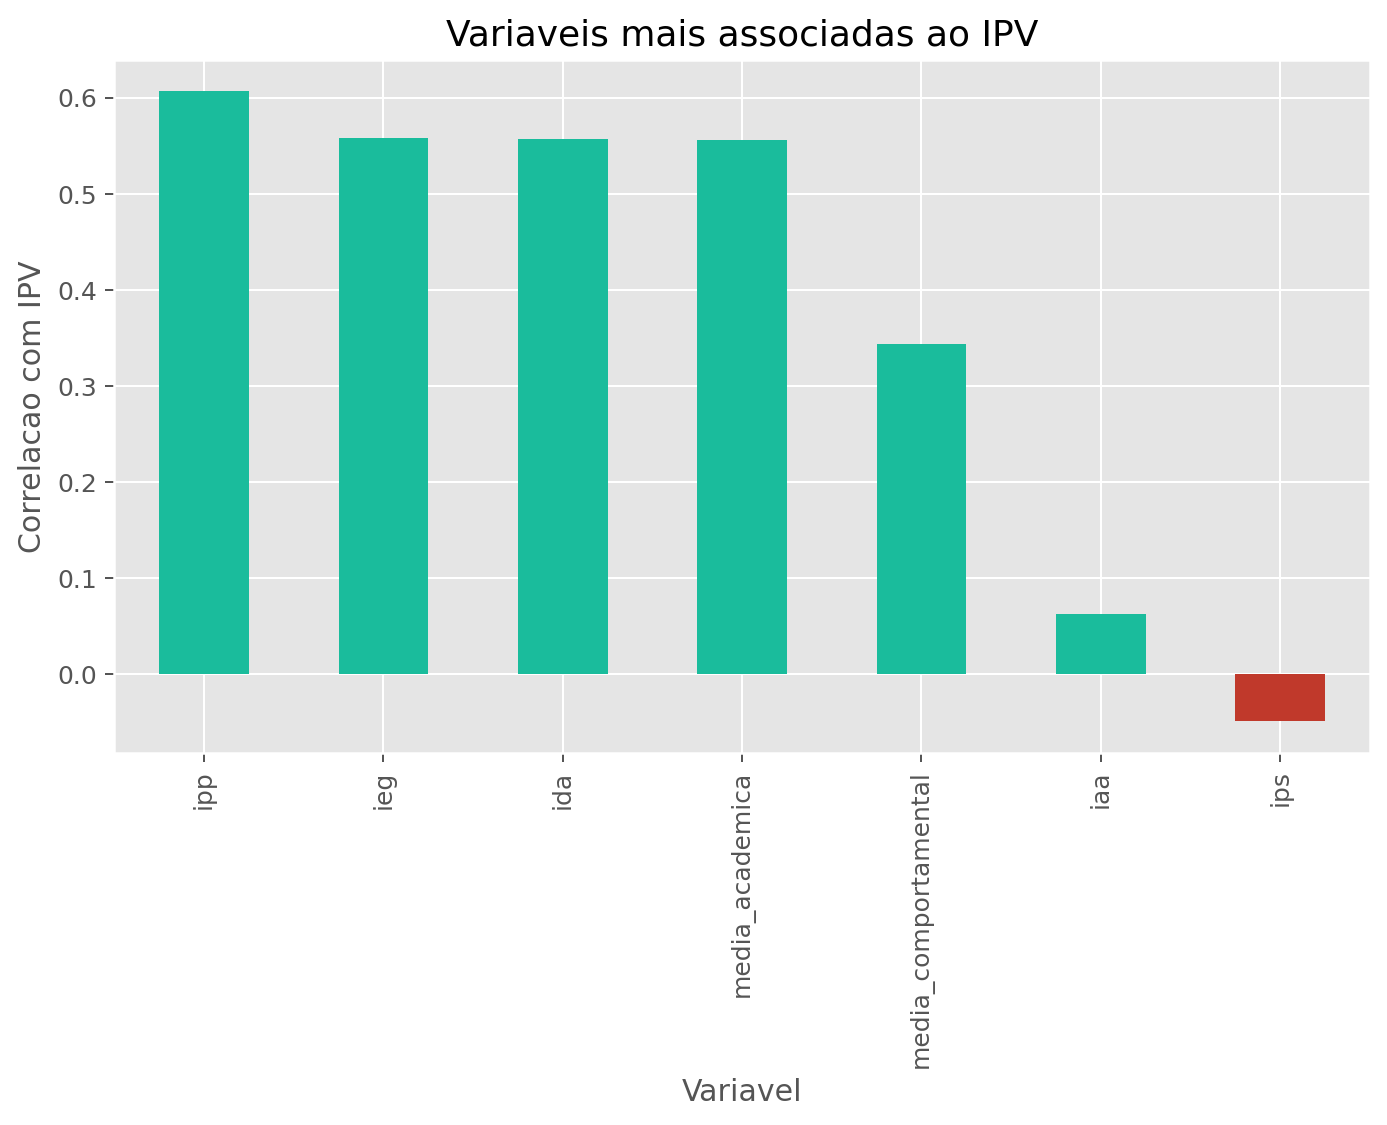

## Pergunta 8 - Multidimensionalidade dos indicadores

**Resposta:** A combinacao mais alinhada ao desempenho global atual e ida, com correlacao de 0.79 com o INDE.  
**Número-chave:** `0.79`  
**Leitura gerencial:** O INDE responde a um ecossistema de fatores; olhar um indicador isolado reduz a capacidade de agir cedo.  
**Ação recomendada:** Adotar paines por aluno com visao combinada de engajamento, academico, psicossocial e psicopedagogico.

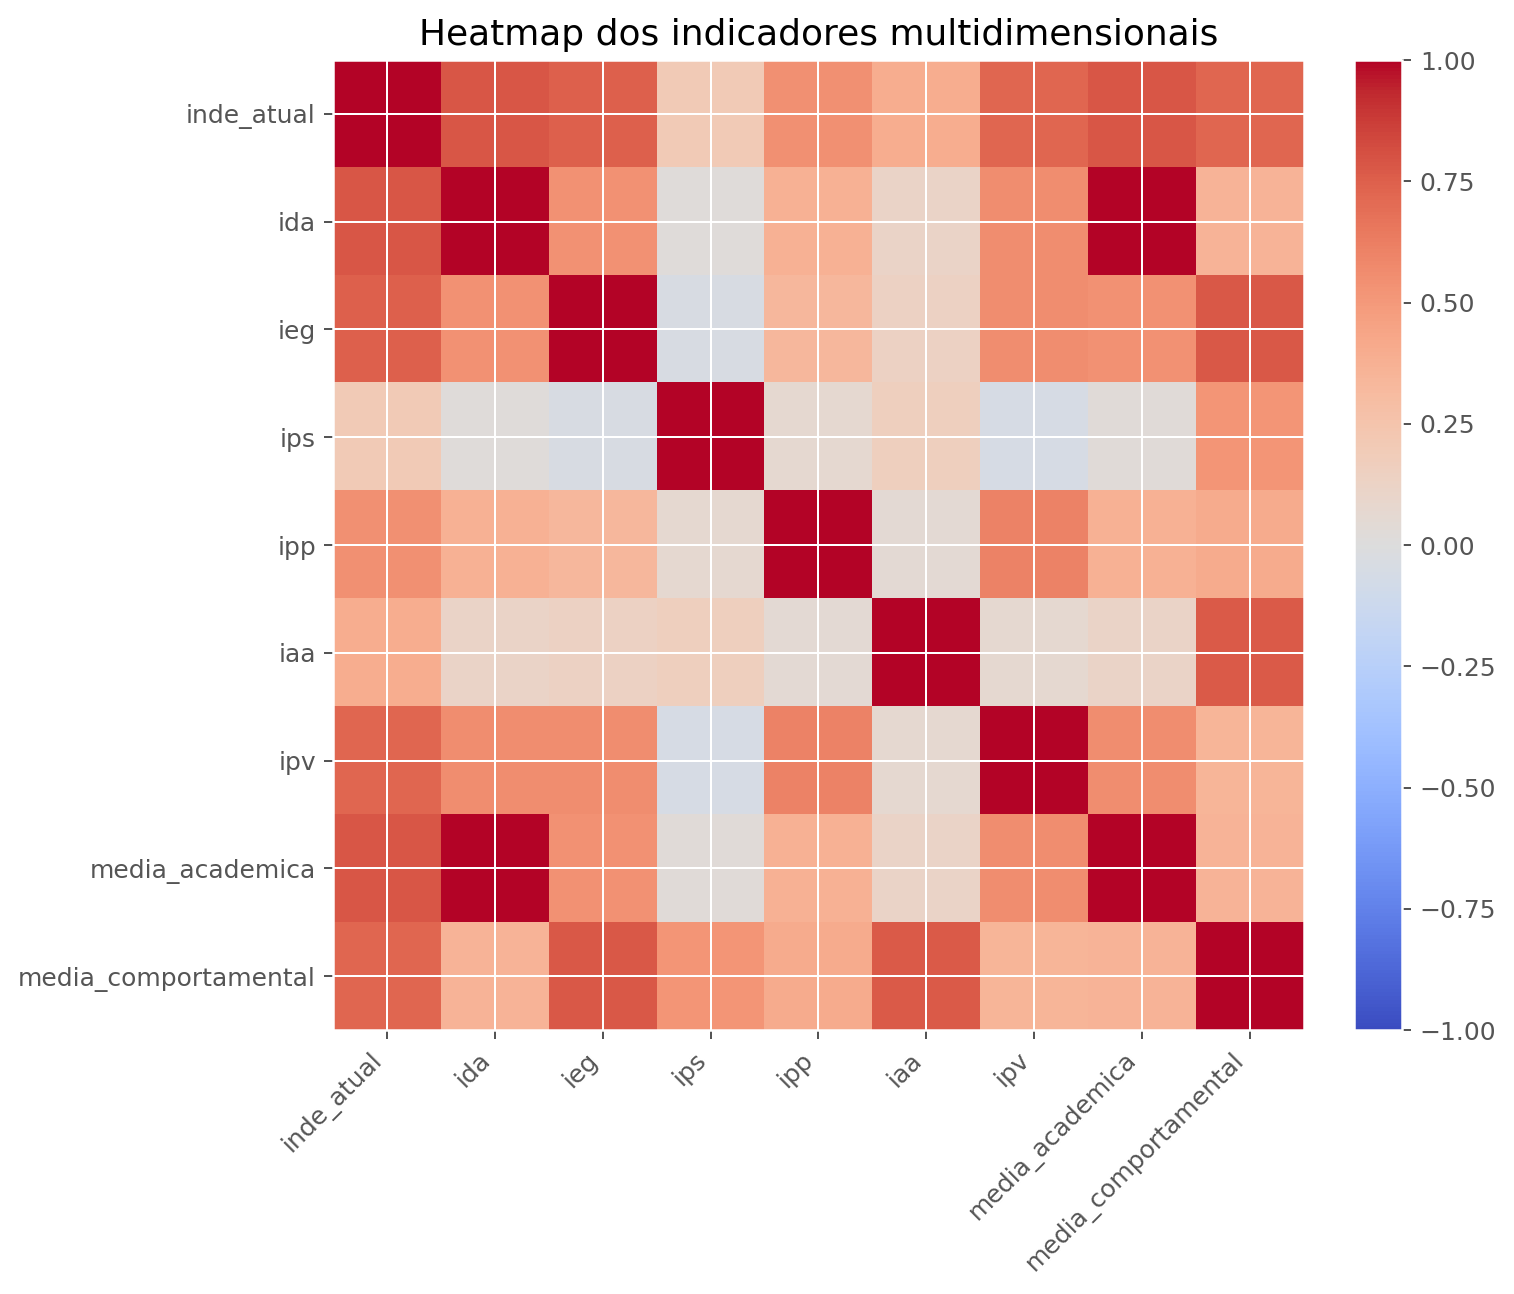

## Pergunta 9 - Previsao de risco com Machine Learning

**Resposta:** No holdout 2023->2024, o modelo regressao_logistica atingiu recall=0.58, precision=0.50 e F2=0.56.  
**Número-chave:** `F2=0.56`  
**Leitura gerencial:** O modelo consegue antecipar parte relevante dos casos de risco usando apenas indicadores disponiveis antes do proximo ciclo.  
**Ação recomendada:** Usar a previsao como fila de triagem, sempre combinada com leitura pedagogica e psicossocial da equipe.

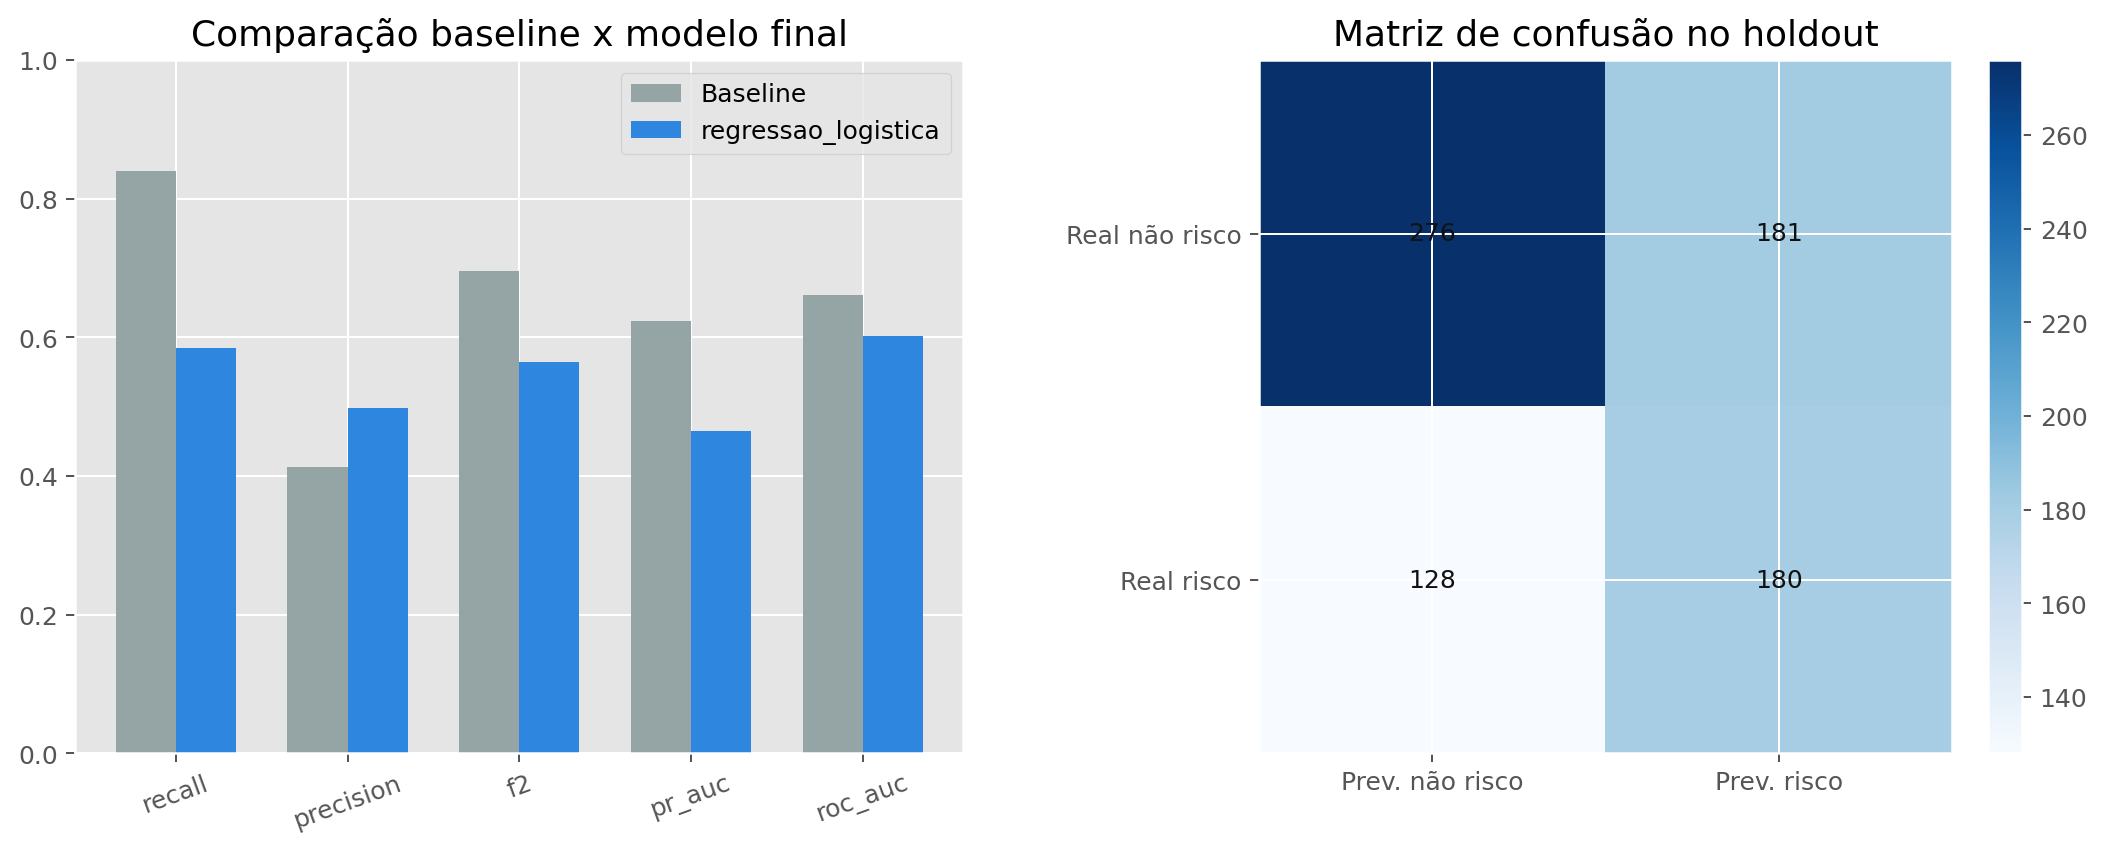

## Pergunta 10 - Efetividade do programa

**Resposta:** Em 2024, o ciclo com melhor desempenho medio foi Topazio, reforcando a efetividade heterogenea do programa.  
**Número-chave:** `Topazio`  
**Leitura gerencial:** O impacto do programa existe, mas nao acontece no mesmo ritmo em todos os ciclos.  
**Ação recomendada:** Customizar metas e cadencia de acompanhamento por ciclo em vez de aplicar a mesma estrategia para toda a base.

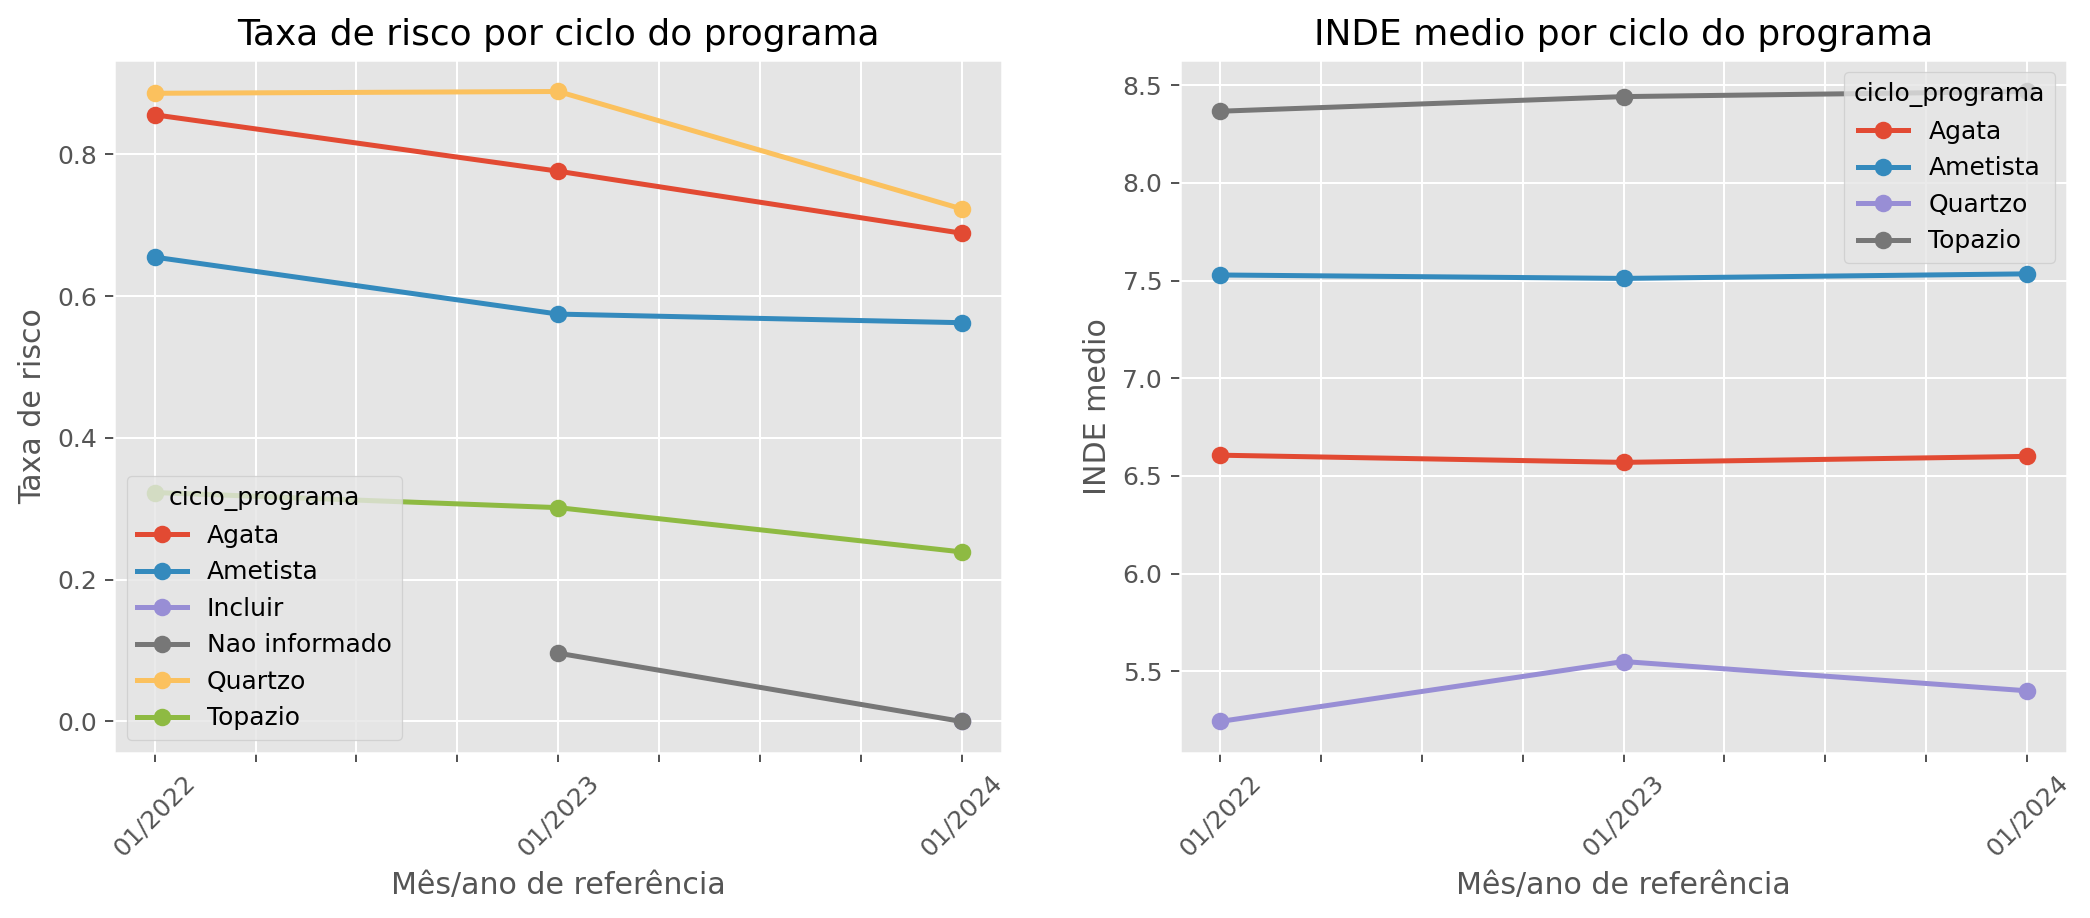

## Pergunta 11 - Tempo de programa e risco futuro

**Resposta:** O risco de proximo ano varia 20.5% entre as faixas de tempo de programa, indicando necessidade de acompanhamento segmentado.  
**Número-chave:** `20.5%`  
**Leitura gerencial:** Tempo de casa altera o padrao de risco, portanto a mesma acao nao serve para veteranos e ingressantes.  
**Ação recomendada:** Segmentar acompanhamento por maturidade no programa, com trilhas especificas para ingressantes e alunos antigos.

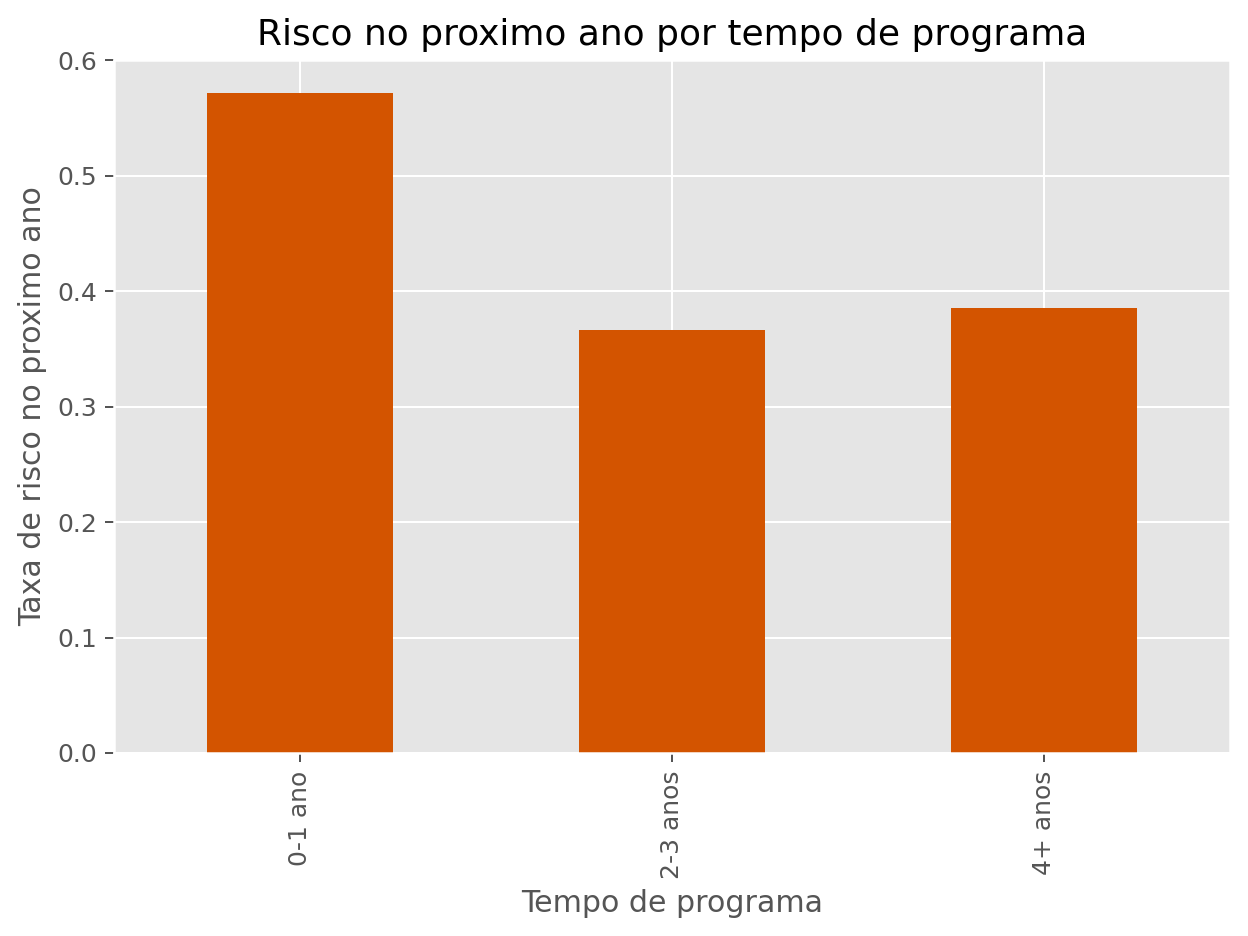

In [3]:
for item in carga_painel["qna_items"]:
    display(Markdown(f"## Pergunta {item['id']} - {item['title']}"))
    linhas = [
        f"**Resposta:** {item['answer']}",
        f"**Número-chave:** `{item['key_number']}`",
        f"**Leitura gerencial:** {item['managerial_takeaway']}",
        f"**Ação recomendada:** {item['recommended_action']}",
    ]
    display(Markdown(("  " + chr(10)).join(linhas)))
    display(Image(filename=str(resolver_caminho_projeto(item["figure"]))))

## 2. Leituras complementares

## Transicoes de risco ano a ano

**Insight:** 10.5% entram em risco no ciclo seguinte, enquanto 20.2% conseguem se recuperar.  
**Número-chave:** `10.5%`  
**Leitura gerencial:** A base exige duas estrategias em paralelo: prevenir novas entradas em risco e recuperar quem ja esta vulneravel.  
**Ação recomendada:** Criar uma fila operacional separando alunos que entram em risco dos que permanecem em risco para intervencoes diferentes.

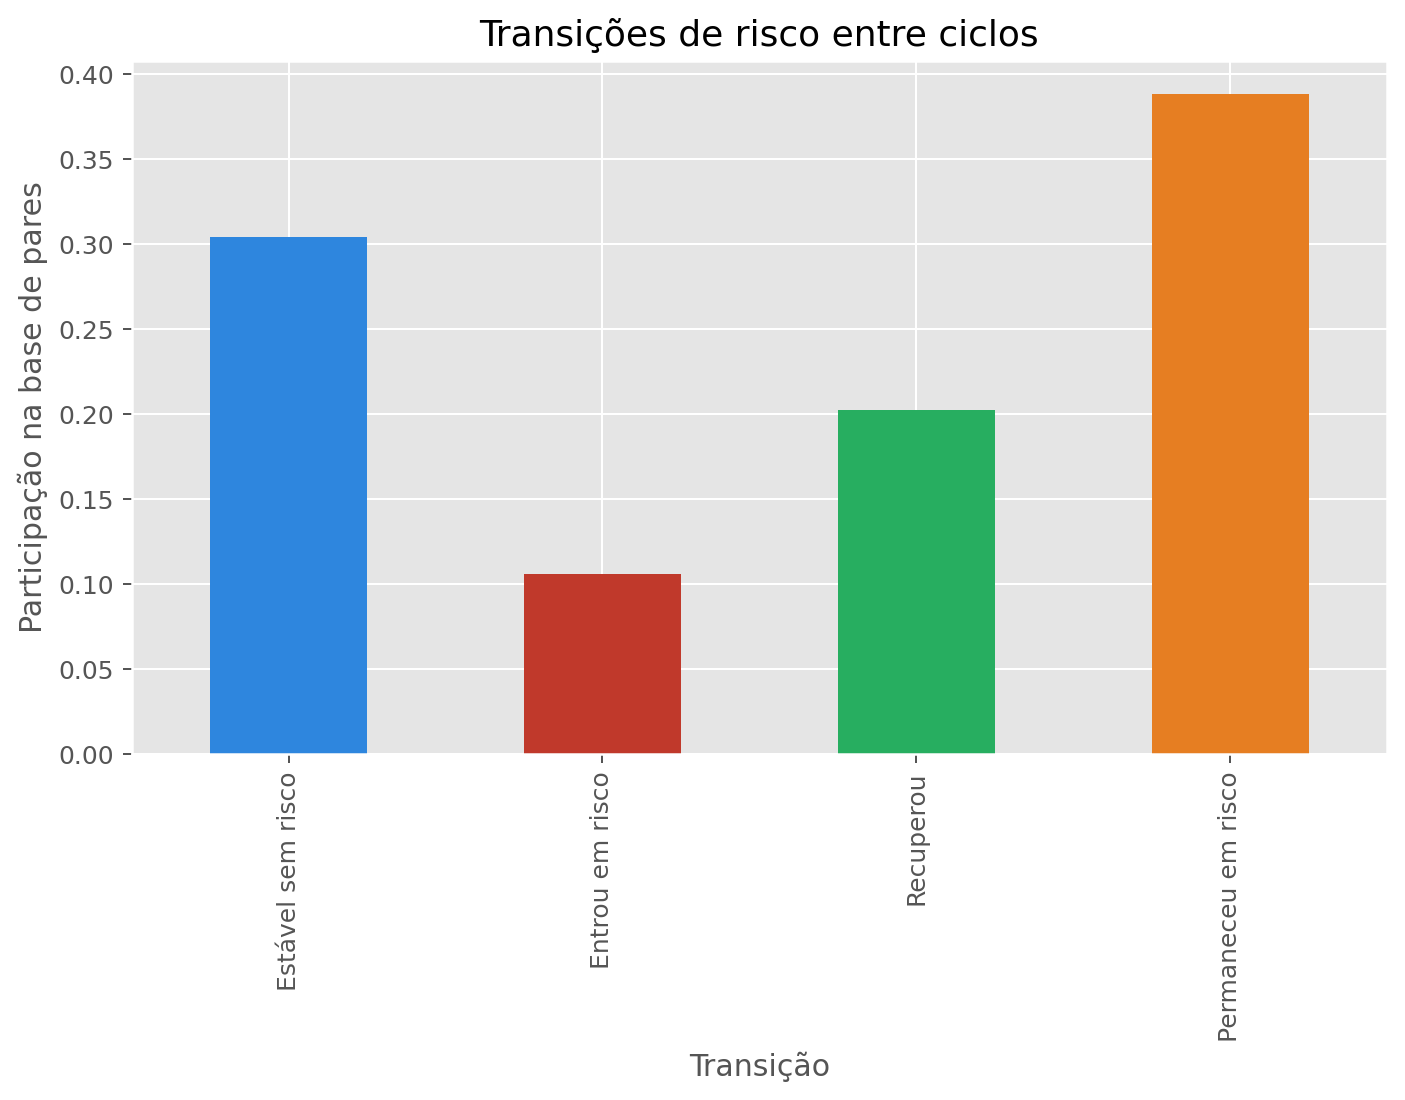

## Queda recente do INDE como alerta preventivo

**Insight:** A diferenca entre a pior e a melhor faixa de variacao do INDE e de 14.1% na taxa de risco do proximo ano.  
**Número-chave:** `14.1%`  
**Leitura gerencial:** A piora recente do INDE funciona como sinal precoce e de facil operacionalizacao para a equipe.  
**Ação recomendada:** Acionar revisao de caso sempre que houver queda relevante de INDE, mesmo antes da consolidacao do risco.

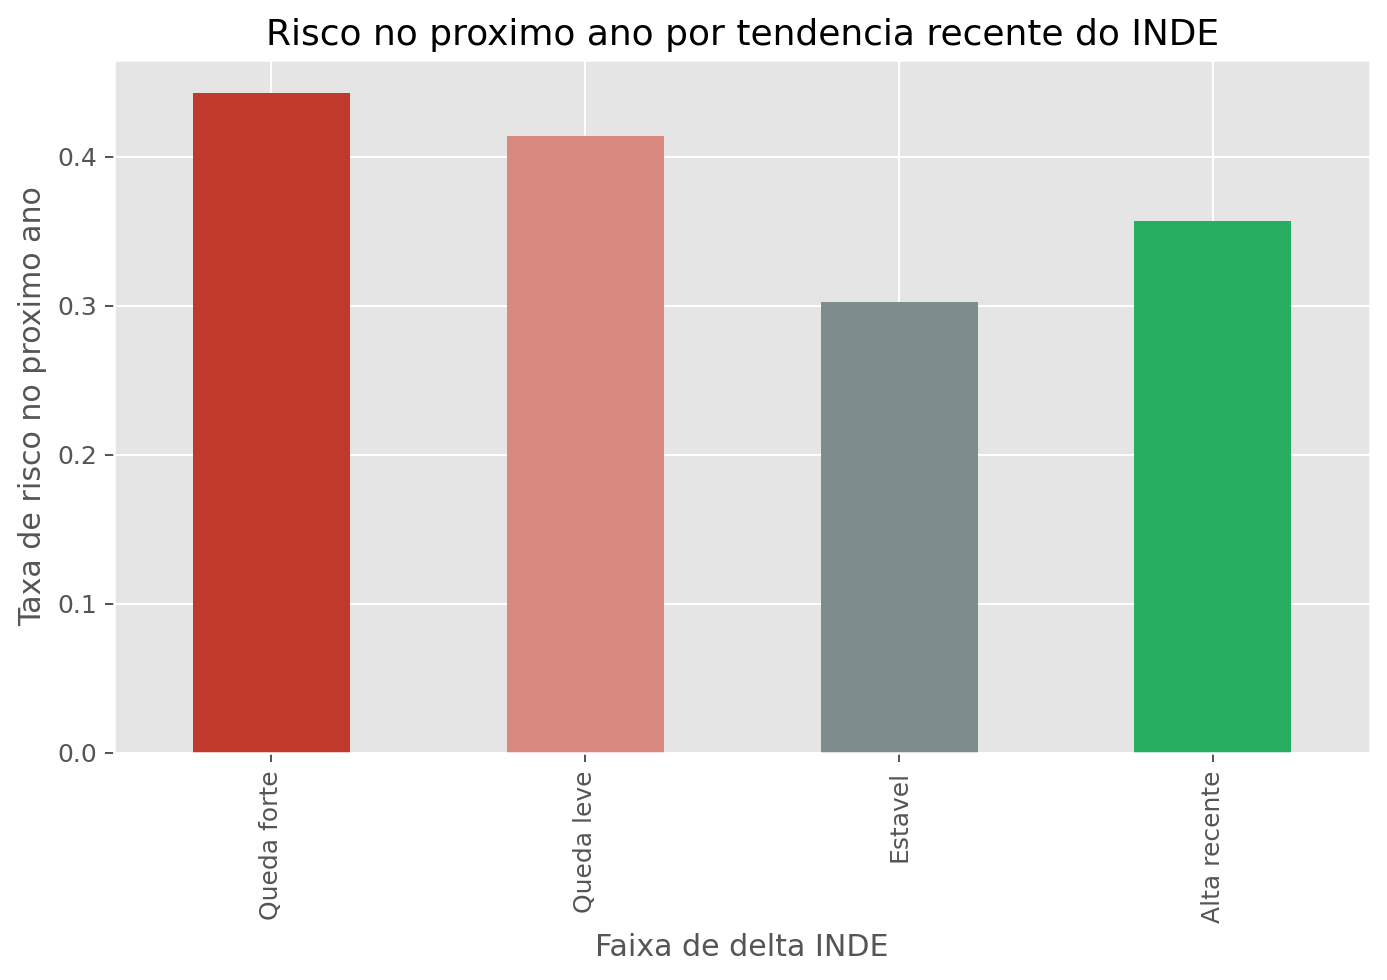

## Cobertura de avaliacoes como sinal operacional

**Insight:** A taxa de risco varia 31.8% entre alunos com baixa e alta cobertura de avaliacoes, sugerindo que monitoramento insuficiente caminha junto com maior vulnerabilidade.  
**Número-chave:** `31.8%`  
**Leitura gerencial:** Menor cobertura avaliativa deixa a equipe mais cega e coincide com maior risco futuro.  
**Ação recomendada:** Garantir nivel minimo de avaliacoes por aluno para reduzir pontos cegos na gestao pedagogica.

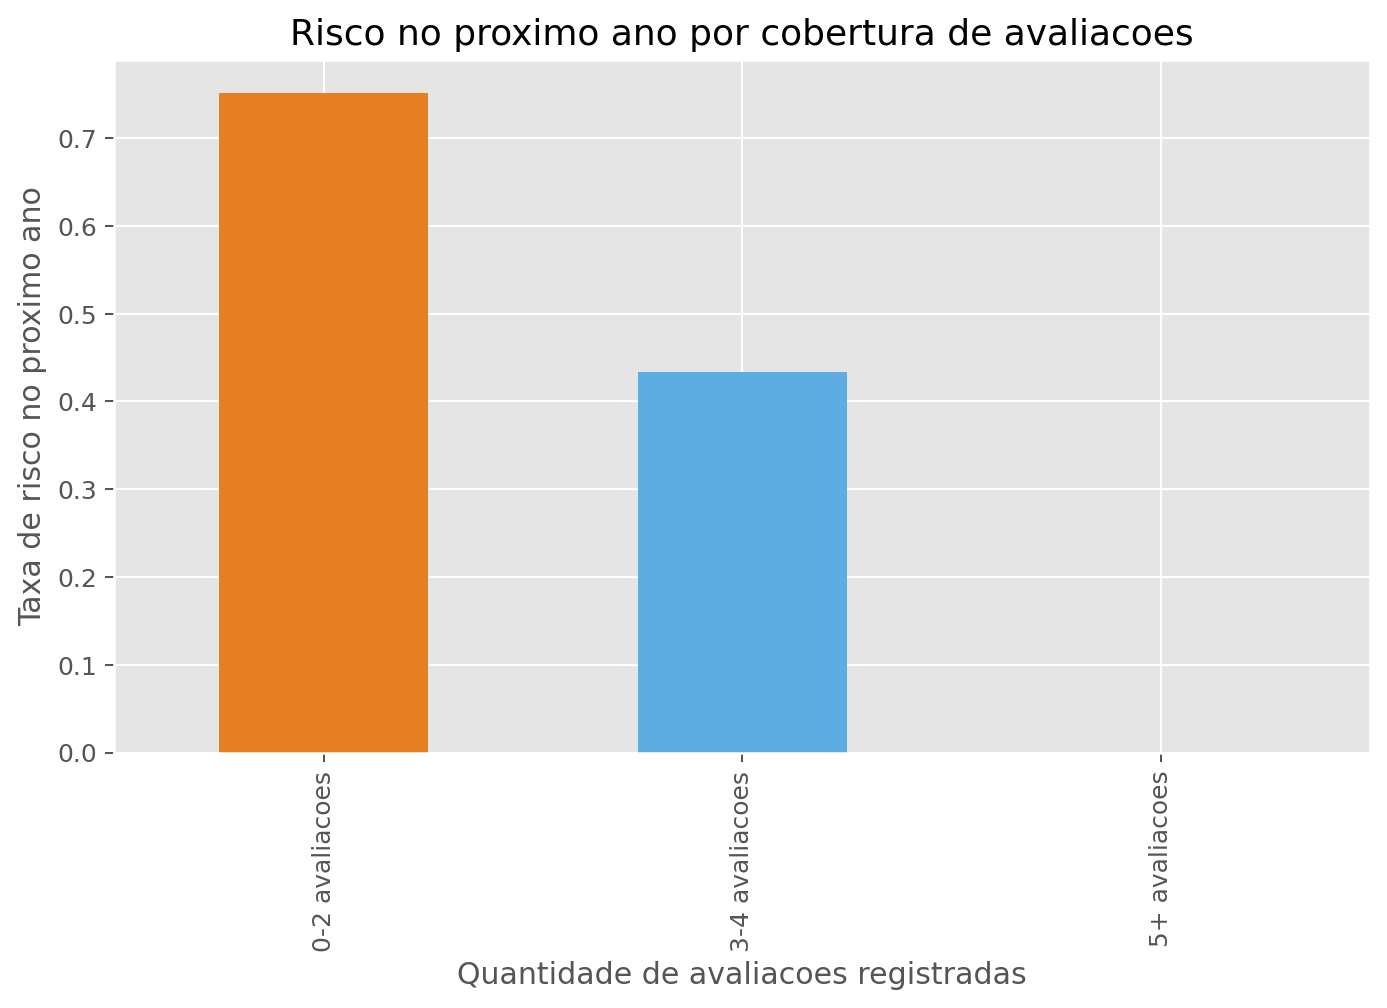

In [4]:
for item in carga_painel["extra_items"]:
    display(Markdown(f"## {item['title']}"))
    linhas = [
        f"**Insight:** {item['answer']}",
        f"**Número-chave:** `{item['key_number']}`",
        f"**Leitura gerencial:** {item['managerial_takeaway']}",
        f"**Ação recomendada:** {item['recommended_action']}",
    ]
    display(Markdown(("  " + chr(10)).join(linhas)))
    display(Image(filename=str(resolver_caminho_projeto(item["figure"]))))

## 3. Métricas do modelo

In [5]:
metricas_holdout = pd.read_csv(MODEL_DIR / "metrics_holdout.csv")
importancia_variaveis = pd.read_csv(MODEL_DIR / "feature_importance.csv").head(15)
display(metricas_holdout)
importancia_variaveis

,model,threshold,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive
0,random_forest,0.20,0.402614,0.402614,1.000000,0.574091,0.771157,0.646004,0.533167,0.0,457.0,0.0,308.0
1,baseline_regra_negocio,0.15,0.454902,0.413078,0.840909,0.554011,0.696611,0.661030,0.624314,89.0,368.0,49.0,259.0
2,xgboost,0.18,0.462745,0.413445,0.798701,0.544850,0.673235,0.516688,0.397764,108.0,349.0,62.0,246.0
3,regressao_logistica,0.17,0.596078,0.498615,0.584416,0.538117,0.564972,0.602354,0.465214,276.0,181.0,128.0,180.0


,feature,importance
0,cat__fase_Alfa,3.254201
1,cat__fase_Fase 8,2.757846
2,num__inde_atual,2.501632
3,cat__fase_7,1.958488
4,cat__fase_0,1.637492
5,cat__fase_Fase 7,1.383210
6,cat__ciclo_programa_Nao informado,1.227234
7,cat__fase_6,1.096110
8,cat__fase_Fase 6,1.095792
9,cat__fase_Fase 2,0.925045


Os mesmos arquivos lidos aqui alimentam a página analítica do app.